In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Wrong because this approach could incorrectly call spouses as siblings

In [2]:
metadata = pd.read_csv("../data/SPARK.iWES_v3.2024_08.sample_metadata.tsv", sep = "\t")
metadata

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False
142354,SP0329625,SF0583492,SP0325663,SP0318140,Male,True,247.0,WES3,2020-08-25,0.041,1.700000,88.0000,GSA-v2,12.0,NaN,False,False
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False


In [3]:
asd_affected = metadata[metadata["asd"]]
asd_affected

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
0,SP0000003,SF0000003,0,SP0000002,Male,True,123.0,WES1,2018-07-27,0.111,2.070000,90.0000,GSA-v1,3.0,NaN,False,False
2,SP0000017,SF0000017,0,0,Male,True,611.0,WES2,2019-11-26,0.179,1.650000,95.0000,GSA-v2,17.0,NaN,False,False
3,SP0000026,SF0000026,SP0255776,SP0000046,Female,True,65.0,WES6,2022-09-12,0.040,1.721284,95.6968,TwistGxS,8.0,NaN,False,False
7,SP0000027,SF0000027,SP0000241,SP0000051,Male,True,147.0,WES1,2018-07-17,0.808,1.800000,92.0000,GSA-v1,9.0,NaN,False,False
8,SP0000034,SF0000027,SP0000241,SP0000051,Male,True,130.0,WES1,2018-08-17,0.088,1.760000,95.0000,GSA-v1,9.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142349,SP0412142,SF0571246,0,SP0424823,Female,True,338.0,WES5,2022-03-21,0.077,1.758782,96.2742,TwistGxS,16.0,NaN,False,False
142351,SP0360833,SF0572144,0,SP0371087,Female,True,347.0,WES4,2021-05-05,0.067,1.730000,98.0000,GSA-v2,14.0,NaN,False,False
142352,SP0318144,SF0583492,0,0,Male,True,192.0,WES3,2020-08-24,0.069,1.730000,98.0000,GSA-v2,12.0,NaN,False,False
142353,SP0318143,SF0583492,SP0325663,SP0318140,Male,True,223.0,WES3,2020-08-24,0.055,1.700000,98.0000,GSA-v2,12.0,NaN,False,False


In [4]:
asd_unaffected = metadata[~metadata["asd"]]
asd_unaffected

,spid,sfid,father,mother,sex,asd,age_m,batch,sequencing_date,seq_pct_contamination,seq_het_hom_ratio,seq_pct_target_20x,genotyping,xhmm_batch,identical_twins,in_spark_wgs,in_searchlight
1,SP0000002,SF0000003,0,0,Female,False,369.0,WES1,2018-08-29,0.055,2.410000,97.0000,GSA-v1,3.0,NaN,False,False
4,SP0000046,SF0000026,0,0,Female,False,522.0,WES6,2022-09-12,0.132,1.815472,95.3584,TwistGxS,8.0,NaN,False,False
5,SP0000062,SF0000026,SP0255776,SP0000046,Female,False,65.0,WES6,2022-09-12,0.095,1.715326,96.1490,TwistGxS,8.0,NaN,False,False
6,SP0000051,SF0000027,0,0,Female,False,530.0,WES1,2018-06-26,0.047,1.750000,94.0000,GSA-v1,9.0,NaN,False,False
10,SP0000241,SF0000027,0,0,Male,False,517.0,WES1,2018-08-02,0.117,1.710000,95.0000,GSA-v1,9.0,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142346,SP0411615,SF0566626,0,0,Male,False,352.0,WES5,2022-03-23,0.071,1.694288,96.7898,TwistGxS,4.0,NaN,False,False
142348,SP0424823,SF0571246,0,0,Female,False,533.0,WES5,2022-05-13,0.068,1.869703,80.8078,TwistGxS,16.0,NaN,False,False
142350,SP0371087,SF0572144,0,0,Female,False,661.0,WES5,2022-03-21,0.061,1.827904,88.4050,TwistGxS,14.0,NaN,False,False
142355,SP0318140,SF0583492,0,0,Female,False,535.0,WES5,2022-03-23,0.069,1.753526,96.7253,TwistGxS,12.0,NaN,False,False


In [5]:
# Approach: Use sfid and parents to merge
# keeps families together, and removes parents (because their recorded parents would be different)
cols_to_keep = ["spid", "sfid", "father", "mother", "age_m"]
sibling_df = pd.merge(asd_affected[cols_to_keep], 
                        asd_unaffected[cols_to_keep], 
                        on = ["father", "mother", "sfid"], 
                        suffixes=("_affected", "_unaffected"))
sibling_df

,spid_affected,sfid,father,mother,age_m_affected,spid_unaffected,age_m_unaffected
0,SP0000026,SF0000026,SP0255776,SP0000046,65.0,SP0000062,65.0
1,SP0000033,SF0000033,SP0000684,SP0000067,93.0,SP0000036,94.0
2,SP0000145,SF0000145,SP0007039,SP0000111,159.0,SP0001673,183.0
3,SP0000164,SF0000164,SP0000231,SP0000131,273.0,SP0000201,131.0
4,SP0000173,SF0000173,0,SP0000140,122.0,SP0000208,109.0
...,...,...,...,...,...,...,...
19741,SP0558734,SF0558734,SP0560038,SP0550207,92.0,SP0558735,53.0
19742,SP0558743,SF0558743,SP0558753,SP0558724,80.0,SP0558746,80.0
19743,SP0559306,SF0559306,SP0561066,SP0559305,146.0,SP0559307,146.0
19744,SP0318144,SF0583492,0,0,192.0,SP0318140,535.0


In [6]:
parent_spids = set(sibling_df["father"]) | set(sibling_df["mother"])
child_spids = set(sibling_df["spid_affected"]) | set(sibling_df["spid_unaffected"])

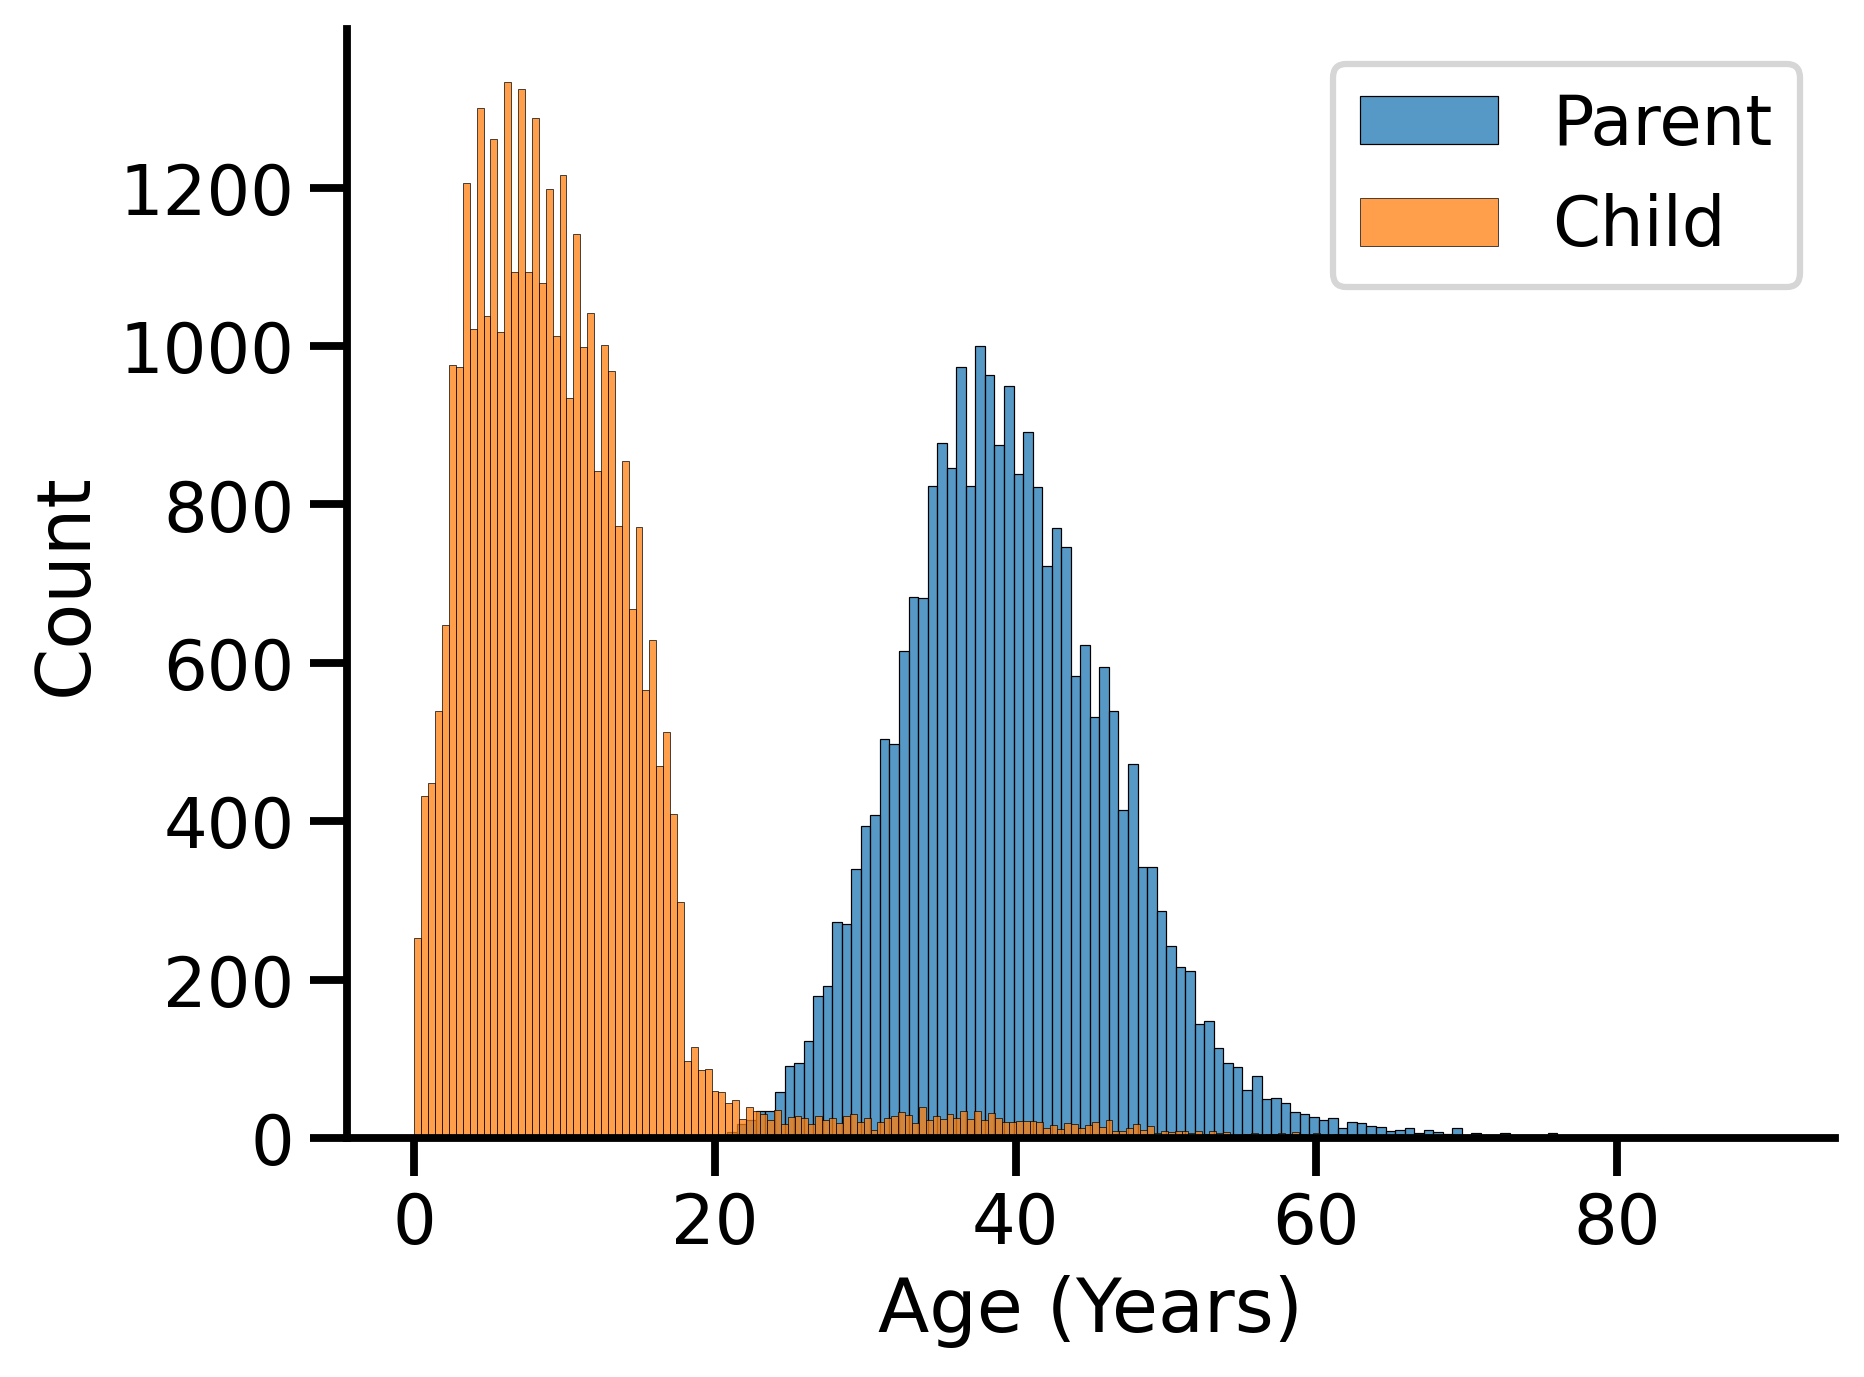

In [7]:
sns.set_context('talk')
plt.figure(dpi = 300)
sns.histplot(metadata[metadata["spid"].isin(parent_spids)]["age_m"]/12, label = "Parent")
sns.histplot(metadata[metadata["spid"].isin(child_spids)]["age_m"]/12, label = "Child")
plt.xlabel("Age (Years)")
sns.despine()
plt.legend()

In [8]:
formatted_sibling_pairs = pd.DataFrame(sibling_df.groupby("spid_affected")["spid_unaffected"].apply(lambda x: ','.join(x))).reset_index()
formatted_sibling_pairs

,spid_affected,spid_unaffected
0,SP0000026,SP0000062
1,SP0000033,SP0000036
2,SP0000145,SP0001673
3,SP0000164,SP0000201
4,SP0000172,SP0000215
...,...,...
18828,SP0558645,SP0558646
18829,SP0558653,SP0558646
18830,SP0558734,SP0558735
18831,SP0558743,SP0558746


In [9]:
formatted_sibling_pairs["spid_affected"].drop_duplicates()

0        SP0000026
1        SP0000033
2        SP0000145
3        SP0000164
4        SP0000172
           ...    
18828    SP0558645
18829    SP0558653
18830    SP0558734
18831    SP0558743
18832    SP0559306
Name: spid_affected, Length: 18833, dtype: object

In [10]:
formatted_sibling_pairs["spid_affected"].to_csv("../data/asd_spids.txt", header = None, index = None)

In [11]:
sibling_df["spid_unaffected"].drop_duplicates()

0        SP0000062
1        SP0000036
2        SP0001673
3        SP0000201
4        SP0000208
           ...    
19741    SP0558735
19742    SP0558746
19743    SP0559307
19744    SP0318140
19745    SP0325663
Name: spid_unaffected, Length: 17995, dtype: object

In [12]:
sibling_df["spid_unaffected"].drop_duplicates().to_csv("../data/sibling_spids.txt", header = None, index = None)

In [13]:
formatted_sibling_pairs[formatted_sibling_pairs["spid_unaffected"].str.contains(",")]

,spid_affected,spid_unaffected
29,SP0000745,"SP0000781,SP0000813"
71,SP0002414,"SP0002509,SP0002477"
72,SP0002449,"SP0002509,SP0002477"
116,SP0003801,"SP0003802,SP0003804"
119,SP0003927,"SP0004479,SP0004513"
...,...,...
18553,SP0544287,"SP0544289,SP0544290"
18637,SP0547754,"SP0547758,SP0547757"
18638,SP0547755,"SP0547758,SP0547757"
18774,SP0554577,"SP0554581,SP0554580"


In [14]:
np.array(formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()) + 1

array([18115,   578,   104,    27,    14])

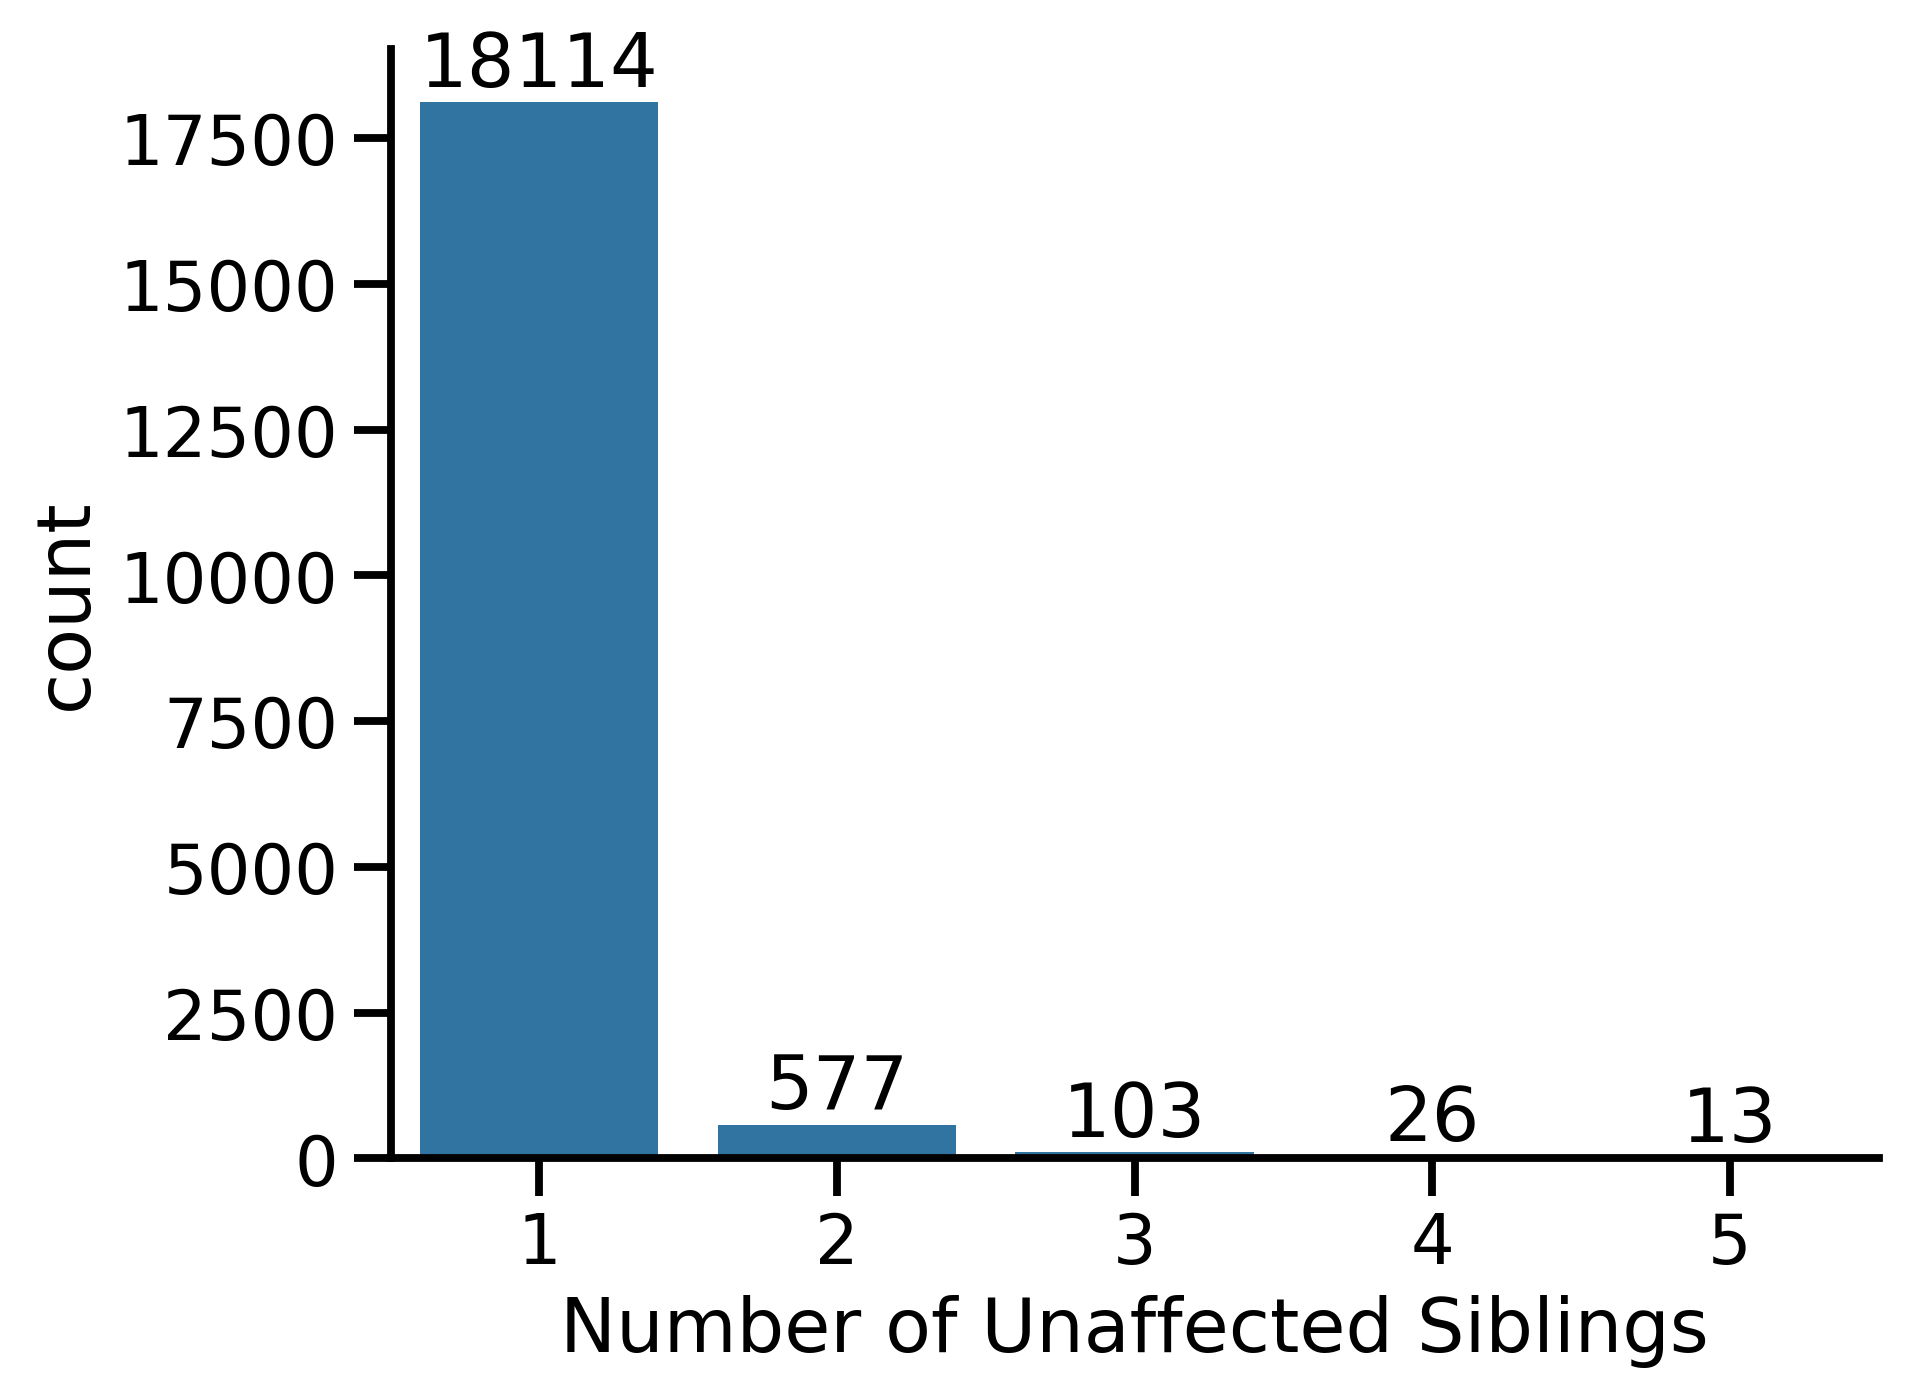

In [15]:
plt.figure(dpi=300)
ax = sns.barplot(
    x=np.arange(1, len(formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()) + 1),
    y=formatted_sibling_pairs["spid_unaffected"].str.count(",").value_counts()
)
plt.xlabel("Number of Unaffected Siblings")
sns.despine()

# Add counts to the top of the bars
ax.bar_label(ax.containers[0])

plt.show()

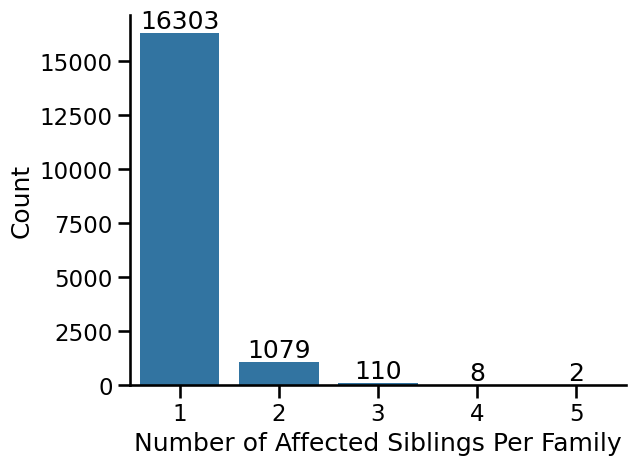

In [16]:
ax = sns.barplot(formatted_sibling_pairs["spid_unaffected"].value_counts().value_counts())
plt.xlabel("Number of Affected Siblings Per Family")
plt.ylabel("Count")

# Add counts to the top of the bars
ax.bar_label(ax.containers[0])
sns.despine()

In [17]:
formatted_sibling_pairs[formatted_sibling_pairs["spid_unaffected"].str.contains(",")].to_csv("../output/sibling_pairs.txt", header = None, index = None)

In [18]:
formatted_sibling_pairs[formatted_sibling_pairs["spid_unaffected"].str.contains(",")]

,spid_affected,spid_unaffected
29,SP0000745,"SP0000781,SP0000813"
71,SP0002414,"SP0002509,SP0002477"
72,SP0002449,"SP0002509,SP0002477"
116,SP0003801,"SP0003802,SP0003804"
119,SP0003927,"SP0004479,SP0004513"
...,...,...
18553,SP0544287,"SP0544289,SP0544290"
18637,SP0547754,"SP0547758,SP0547757"
18638,SP0547755,"SP0547758,SP0547757"
18774,SP0554577,"SP0554581,SP0554580"
